https://www.kaggle.com/datasets/willianoliveiragibin/illicit-drugs

# Drogas ilícitas
Drogas ilícitas são drogas que foram proibidas pela legislação internacional sobre drogas.

# Dados

Drogas ilícitas são drogas que foram proibidas por tratados internacionais de controle de drogas.1

As estatísticas internacionais geralmente se concentram em quatro grupos diferentes de drogas ilícitas: opioides, cocaína, cannabis e anfetaminas. No entanto, uma série de outras drogas ilícitas está incluída em tratados internacionais de controle de drogas, incluindo drogas à base de plantas e alucinógenos sintéticos. A publicação do UNODC “Terminologia e Informação sobre Drogas”² contém uma lista abrangente de drogas ilícitas.

O consumo excessivo ou a dependência de drogas ilícitas pode afetar a saúde geral, o bem-estar mental e, em muitos casos, o bem-estar de outras pessoas. Nem todas as drogas ilícitas têm impactos semelhantes na saúde e no bem-estar: algumas causam muito menos danos do que outras.

Nesta página, você encontra uma lista de insights importantes, bem como uma lista de visualizações sobre o uso de drogas ilícitas. Ela oferece uma visão geral do uso de drogas ilícitas, transtornos de dependência e alguns de seus impactos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_death = pd.read_csv('deaths-illicit-drugs NEW.csv')

In [2]:
df_death

,COUNTRY,Code,Year,Deaths - Drug use disorders - Sex: Both - Age: All Ages (Number),"Deaths that are from all causes attributed to drug use, in both sexes aged all ages"
0,American Samoa,ASM,1990,0,13.090.138
1,Andorra,AND,1990,0,20.659.685
2,Antigua and Barbuda,ATG,1990,0,6.584.844
3,Bahamas,BHS,1990,0,39.783.647
4,Barbados,BRB,1990,0,26.759.732
...,...,...,...,...,...
6955,World,OWID_WRL,2019,128083,494491.7
6956,High Income (WB),0,2019,0,166330.19
6957,Low Income (WB),0,2019,0,12.577.318
6958,Lower Middle Income (WB),0,2019,0,150491.05


In [3]:
#Informações
df_death.info()
df_death.head()
df_death.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6960 entries, 0 to 6959
Data columns (total 5 columns):
 #   Column                                                                               Non-Null Count  Dtype 
---  ------                                                                               --------------  ----- 
 0   COUNTRY                                                                              6960 non-null   object
 1   Code                                                                                 6960 non-null   object
 2   Year                                                                                 6960 non-null   int64 
 3   Deaths - Drug use disorders - Sex: Both - Age: All Ages (Number)                     6960 non-null   int64 
 4   Deaths that are from all causes attributed to drug use, in both sexes aged all ages  6960 non-null   object
dtypes: int64(2), object(3)
memory usage: 272.0+ KB


,Year,Deaths - Drug use disorders - Sex: Both - Age: All Ages (Number)
count,6960.000000,6960.000000
mean,2004.500000,2406.845402
std,8.656063,10299.186803
min,1990.000000,0.000000
25%,1997.000000,4.000000
50%,2004.500000,29.000000
75%,2012.000000,202.000000
max,2019.000000,128083.000000


In [4]:
#Valores Ausentes
df_death.isna().sum()

COUNTRY                                                                                0
Code                                                                                   0
Year                                                                                   0
Deaths - Drug use disorders - Sex: Both - Age: All Ages (Number)                       0
Deaths that are from all causes attributed to drug use, in both sexes aged all ages    0
dtype: int64

In [5]:
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

df_death = df_death.rename(columns={
    'Deaths - Drug use disorders - Sex: Both - Age: All Ages (Number)': 'Deaths_Drug_Use_Disorders',
    'Deaths that are from all causes attributed to drug use, in both sexes aged all ages': 'Total_Deaths_Attributed_to_Drug_Use'
})

In [6]:
for col in ['Deaths_Drug_Use_Disorders', 'Total_Deaths_Attributed_to_Drug_Use']:
    df_death[col] = df_death[col].astype(str).str.replace('.', '', regex=False)
    df_death[col] = pd.to_numeric(df_death[col], errors='coerce')

In [7]:
df_death['Code'].fillna('Unknown', inplace=True)
df_death['Code'] = df_death['Code'].replace('0', 'Unknown')
df_death['Code'] = df_death['Code'].astype(str)

C:\Users\Usuário\AppData\Local\Temp\ipykernel_13784\3212910977.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_death['Code'].fillna('Unknown', inplace=True)


In [8]:
df_death = df_death[~df_death['COUNTRY'].isin(['World', 'World Bank High Income', 'World Bank Low Income', 'World Bank Lower Middle Income', 'World Bank Upper Middle Income'])]

print(df_death.info())
print(df_death.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 6810 entries, 0 to 6959
Data columns (total 5 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   COUNTRY                              6810 non-null   object
 1   Code                                 6810 non-null   object
 2   Year                                 6810 non-null   int64 
 3   Deaths_Drug_Use_Disorders            6810 non-null   int64 
 4   Total_Deaths_Attributed_to_Drug_Use  6810 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 319.2+ KB
None
COUNTRY                                0
Code                                   0
Year                                   0
Deaths_Drug_Use_Disorders              0
Total_Deaths_Attributed_to_Drug_Use    0
dtype: int64


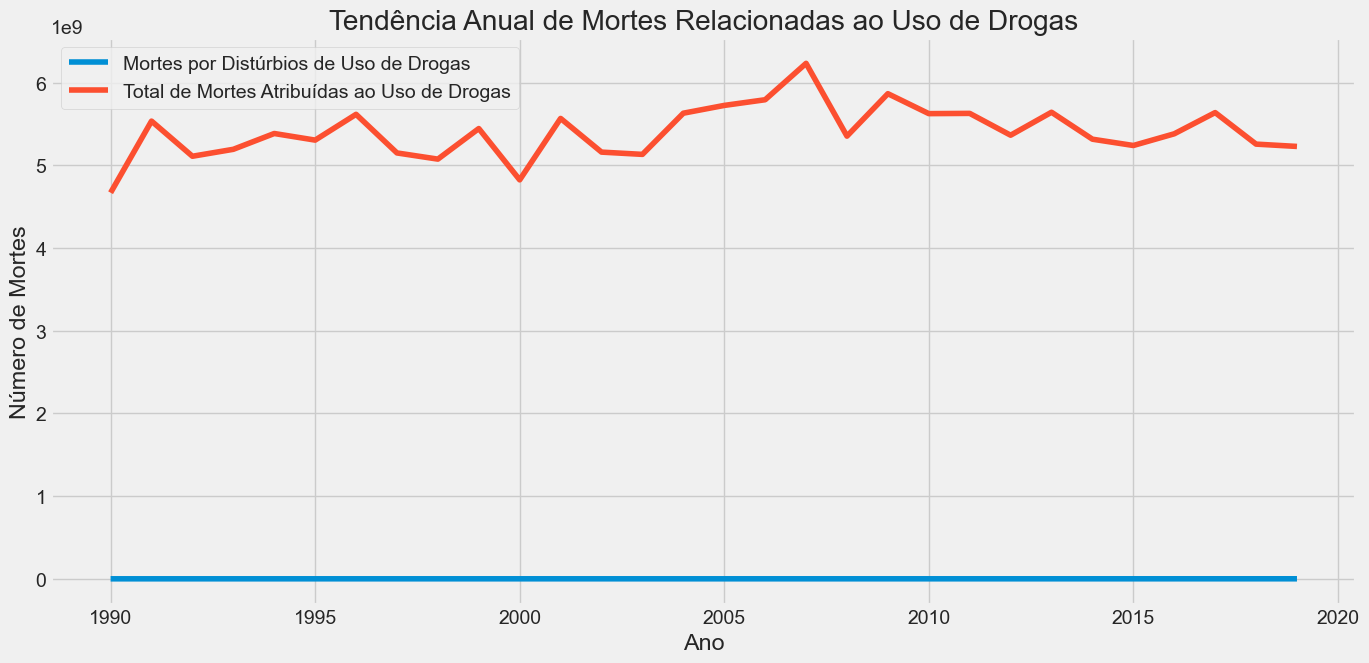

In [9]:
#Por ano e somando as mortes
df_time = df_death.groupby('Year')[['Deaths_Drug_Use_Disorders', 'Total_Deaths_Attributed_to_Drug_Use']].sum().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(data=df_time, x='Year', y='Deaths_Drug_Use_Disorders', label='Mortes por Distúrbios de Uso de Drogas')
sns.lineplot(data=df_time, x='Year', y='Total_Deaths_Attributed_to_Drug_Use', label='Total de Mortes Atribuídas ao Uso de Drogas')
plt.title('Tendência Anual de Mortes Relacionadas ao Uso de Drogas')
plt.xlabel('Ano')
plt.ylabel('Número de Mortes')
plt.legend()
plt.show()

De 1990 a 2019, o número de mortes atribuídas ao uso de drogas (linha laranja) foi significativamente maior do que o número de mortes por transtornos do uso de drogas (linha azul). A maioria das mortes relacionadas a drogas foi causada por fatores diretos e imediatos associados ao uso, como overdose e intoxicação, em vez de condições crônicas de saúde decorrentes do vício.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_13784\3326903337.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_country_2019.values, y=df_country_2019.index, palette='flare')


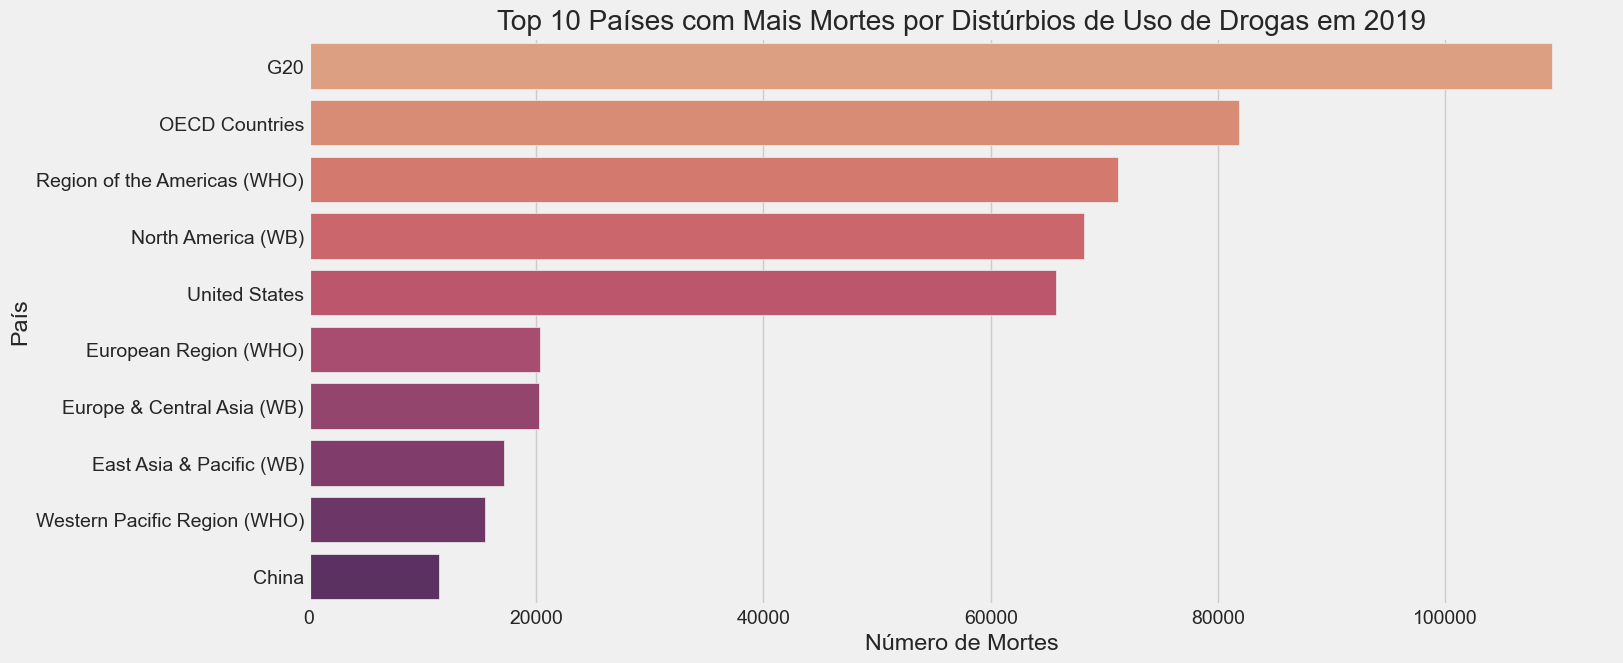

In [10]:
#2019
df_2019 = df_death[df_death['Year'] == 2019]

df_country_2019 = df_2019.groupby('COUNTRY')['Deaths_Drug_Use_Disorders'].sum().sort_values(ascending=False).head(10)

#10 principais países
plt.figure(figsize=(15, 7))
sns.barplot(x=df_country_2019.values, y=df_country_2019.index, palette='flare')
plt.title('Top 10 Países com Mais Mortes por Distúrbios de Uso de Drogas em 2019')
plt.xlabel('Número de Mortes')
plt.ylabel('País')
plt.show()

Em 2019, os maiores números de mortes por distúrbios de uso de drogas foram observados em grandes blocos econômicos ou regiões. O G20 lidera com o maior número de mortes, seguido pelos países da OCDE (Organização para a Cooperação e Desenvolvimento Econômico) e a Região das Américas.
Os Estados Unidos se destacam, com um número de mortes significativamente maior que a China, que aparece no final da lista. 

In [11]:
#Coluna para numérico
df_death['Total_Deaths_Attributed_to_Drug_Use'] = df_death['Total_Deaths_Attributed_to_Drug_Use'].astype(str).str.replace('.', '', regex=False)
df_death['Total_Deaths_Attributed_to_Drug_Use'] = pd.to_numeric(df_death['Total_Deaths_Attributed_to_Drug_Use'], errors='coerce')

C:\Users\Usuário\AppData\Local\Temp\ipykernel_13784\4166890129.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df_country_2019.values, y=df_country_2019.index, palette='flare')


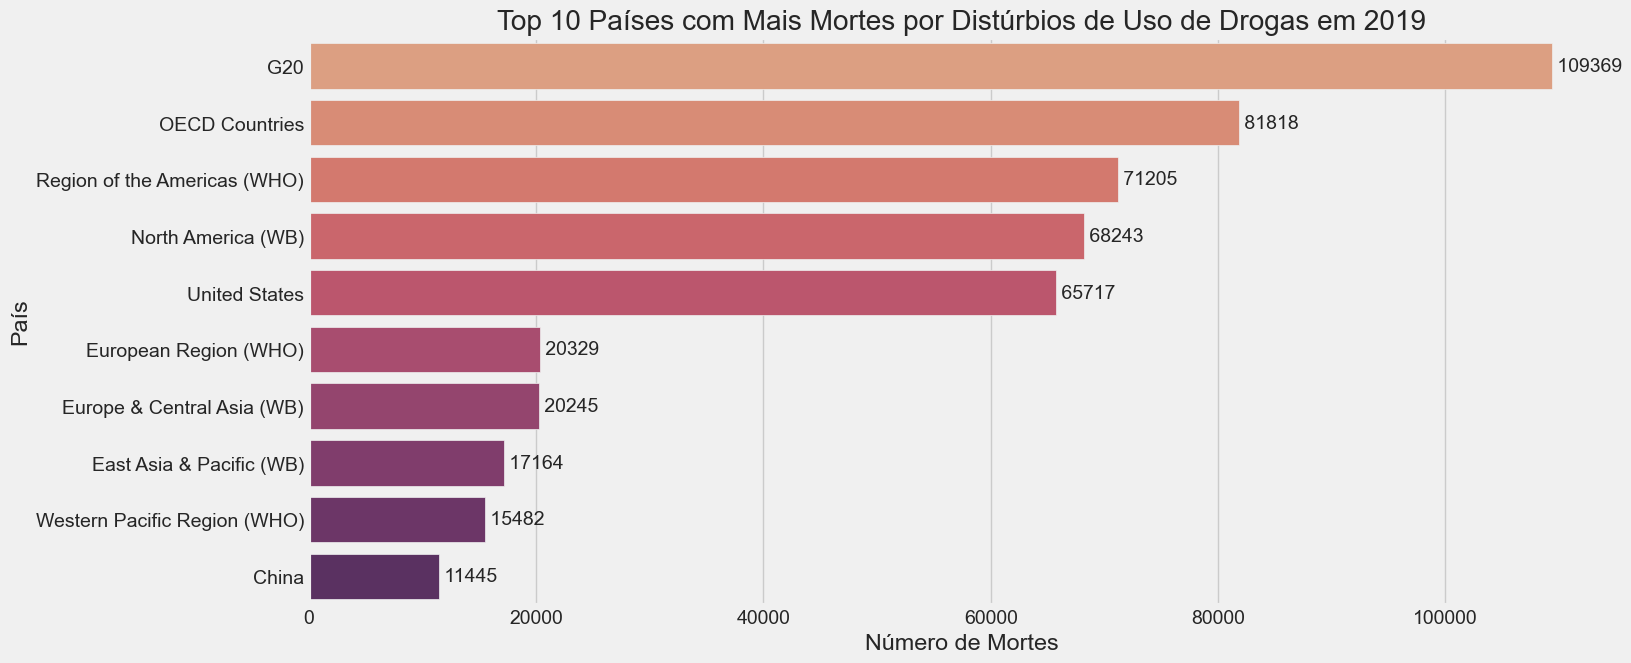

In [12]:
#Top 10 países com mais mortes
df_2019 = df_death[df_death['Year'] == 2019]
df_country_2019 = df_2019.groupby('COUNTRY')['Deaths_Drug_Use_Disorders'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(15, 7))
ax = sns.barplot(x=df_country_2019.values, y=df_country_2019.index, palette='flare')

for index, value in enumerate(df_country_2019.values):
    ax.text(value, index, f' {value}', va='center')

plt.title('Top 10 Países com Mais Mortes por Distúrbios de Uso de Drogas em 2019')
plt.xlabel('Número de Mortes')
plt.ylabel('País')
plt.show()

O G20 lidera com o maior número de mortes, seguido pelos países da OCDE (Organização para a Cooperação e Desenvolvimento Econômico) e a Região das Américas. Os Estados Unidos se destacam, com 65.717 mortes, enquanto a China aparece no final da lista, com 11.445.

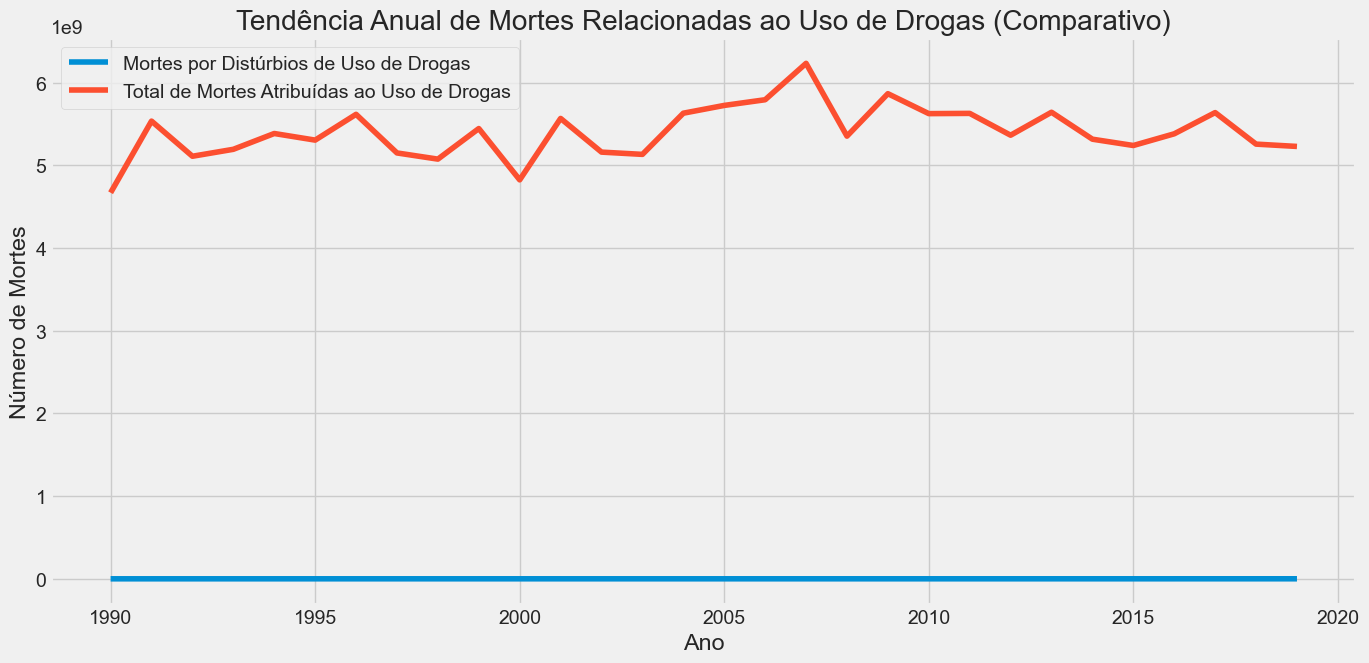

In [13]:
#Comparativo
df_time = df_death.groupby('Year')[['Deaths_Drug_Use_Disorders', 'Total_Deaths_Attributed_to_Drug_Use']].sum().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(data=df_time, x='Year', y='Deaths_Drug_Use_Disorders', label='Mortes por Distúrbios de Uso de Drogas')
sns.lineplot(data=df_time, x='Year', y='Total_Deaths_Attributed_to_Drug_Use', label='Total de Mortes Atribuídas ao Uso de Drogas')
plt.title('Tendência Anual de Mortes Relacionadas ao Uso de Drogas (Comparativo)')
plt.xlabel('Ano')
plt.ylabel('Número de Mortes')
plt.legend()
plt.show()

A maioria das mortes relacionadas ao uso de drogas entre 1990 e 2019 foi atribuída a causas diretas, como overdoses e intoxicações agudas, em vez de transtornos crônicos do uso de drogas.
Essa diferença sugere que a principal ameaça à vida relacionada às drogas é a consequência imediata do seu consumo, e não as complicações de saúde a longo prazo.

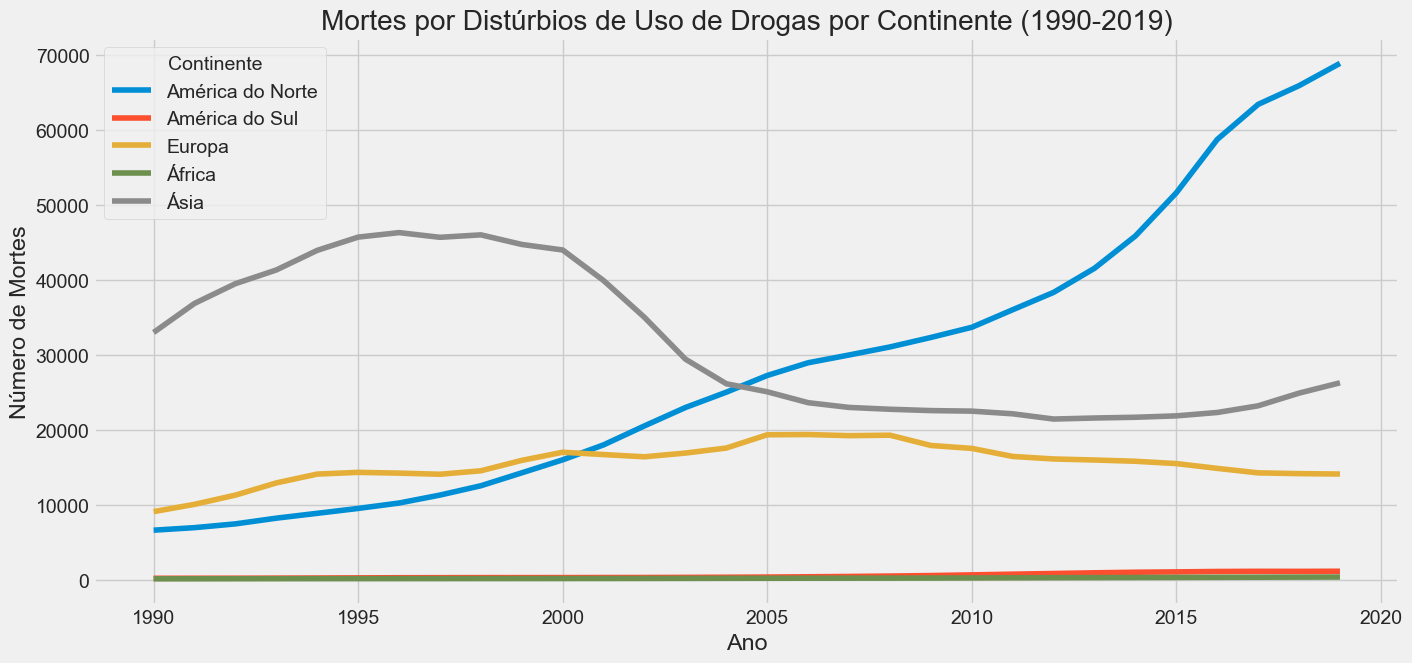

In [14]:
#Por continente
continent_mapping = {
    'China': 'Ásia',
    'United States': 'América do Norte',
    'India': 'Ásia',
    'Russia': 'Europa',
    'Brazil': 'América do Sul',
    'Indonesia': 'Ásia',
    'Pakistan': 'Ásia',
    'Bangladesh': 'Ásia',
    'Nigeria': 'África',
    'Japan': 'Ásia',
    'Germany': 'Europa',
    'United Kingdom': 'Europa',
    'France': 'Europa',
    'Italy': 'Europa',
    'Canada': 'América do Norte',
    'Mexico': 'América do Norte',
    'Iran': 'Ásia',
    'Vietnam': 'Ásia',
    'Ukraine': 'Europa',
    'Egypt': 'África'
}

df_death['Continent'] = df_death['COUNTRY'].map(continent_mapping)

df_death.dropna(subset=['Continent'], inplace=True)

df_continent_time = df_death.groupby(['Year', 'Continent'])['Deaths_Drug_Use_Disorders'].sum().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(data=df_continent_time, x='Year', y='Deaths_Drug_Use_Disorders', hue='Continent')
plt.title('Mortes por Distúrbios de Uso de Drogas por Continente (1990-2019)')
plt.xlabel('Ano')
plt.ylabel('Número de Mortes')
plt.legend(title='Continente')
plt.show()

O aumento global de mortes por distúrbios de uso de drogas foi impulsionado principalmente pelo crescimento vertiginoso na América do Norte, enquanto outras regiões viram estabilidade ou até mesmo queda nos números.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_13784\4170377193.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df_rate_2019.values, y=df_rate_2019.index, palette='icefire')


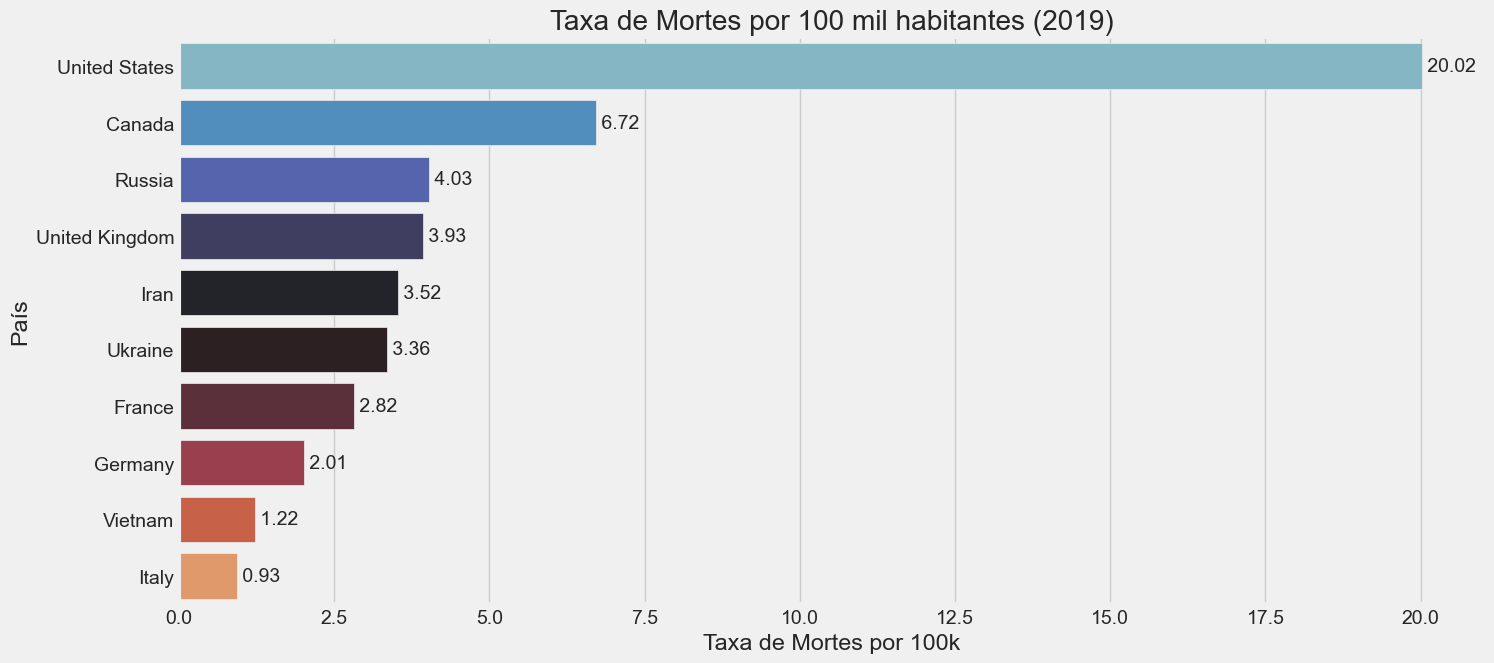

In [15]:
#População
populacao_mapping = {
    'China': 1433783686,
    'United States': 328239523,
    'India': 1366417754,
    'Russia': 145934462,
    'Brazil': 211049527,
    'Indonesia': 270625568,
    'Pakistan': 216565318,
    'Bangladesh': 163046161,
    'Nigeria': 200963599,
    'Japan': 126264931,
    'Germany': 83517045,
    'United Kingdom': 67530172,
    'France': 65129000,
    'Italy': 60477209,
    'Canada': 37589262,
    'Mexico': 127575529,
    'Iran': 82913906,
    'Vietnam': 96462106,
    'Ukraine': 43993638,
    'Egypt': 100388073
}

df_death['Population'] = df_death['COUNTRY'].map(populacao_mapping)

df_death.dropna(subset=['Population'], inplace=True)

df_death['Deaths_per_100k'] = (df_death['Deaths_Drug_Use_Disorders'] / df_death['Population']) * 100000

df_rate_2019 = df_death[df_death['Year'] == 2019].groupby('COUNTRY')['Deaths_per_100k'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(15, 7))
ax = sns.barplot(x=df_rate_2019.values, y=df_rate_2019.index, palette='icefire')
plt.title('Taxa de Mortes por 100 mil habitantes (2019)')
plt.xlabel('Taxa de Mortes por 100k')
plt.ylabel('País')

for index, value in enumerate(df_rate_2019.values):
    ax.text(value, index, f' {value:.2f}', va='center')

plt.show()

A taxa dos EUA, de 20,02 mortes por 100 mil habitantes, é aproximadamente três vezes maior que a do Canadá (o segundo colocado com 6,72) e mais de 20 vezes maior que a da Itália (o último país da lista com 0,93).

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from prophet import Prophet
import numpy as np

Erro Quadrático Médio (MSE): 23349867.57


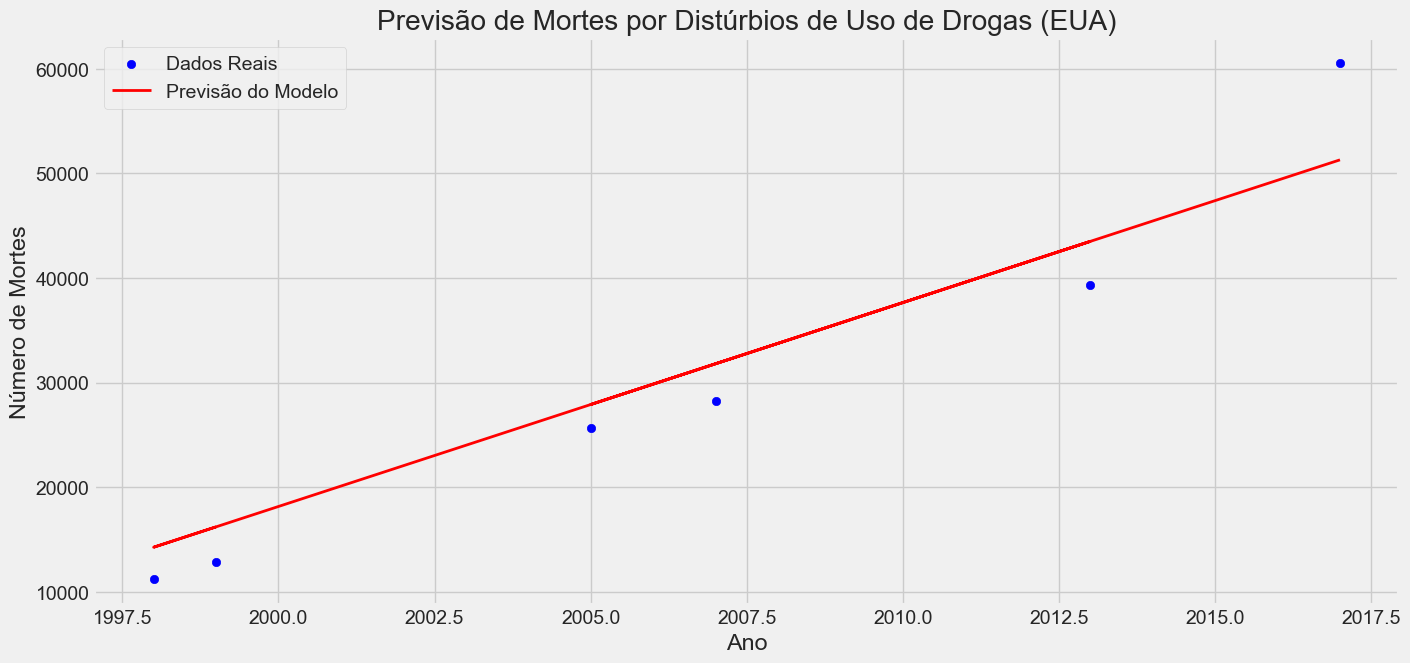

Mortes previstas para 2025: 66887


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:
#Modelagem
df_us = df_death[df_death['COUNTRY'] == 'United States']

X = df_us[['Year']]
y = df_us['Deaths_Drug_Use_Disorders']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f'Erro Quadrático Médio (MSE): {mse:.2f}')

plt.figure(figsize=(15, 7))
plt.scatter(X_test, y_test, color='blue', label='Dados Reais')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Previsão do Modelo')
plt.title('Previsão de Mortes por Distúrbios de Uso de Drogas (EUA)')
plt.xlabel('Ano')
plt.ylabel('Número de Mortes')
plt.legend()
plt.show()

future_year = np.array([[2025]])
predicted_deaths = model.predict(future_year)
print(f'Mortes previstas para 2025: {predicted_deaths[0]:.0f}')

De 1998 a 2017, o modelo de previsão subestimou consistentemente o número real de mortes por distúrbios de uso de drogas nos Estados Unidos. O aumento real de mortes foi mais acelerado e drástico do que o previsto pelo modelo, indicando uma crise de drogas que se intensificou além das expectativas iniciais.

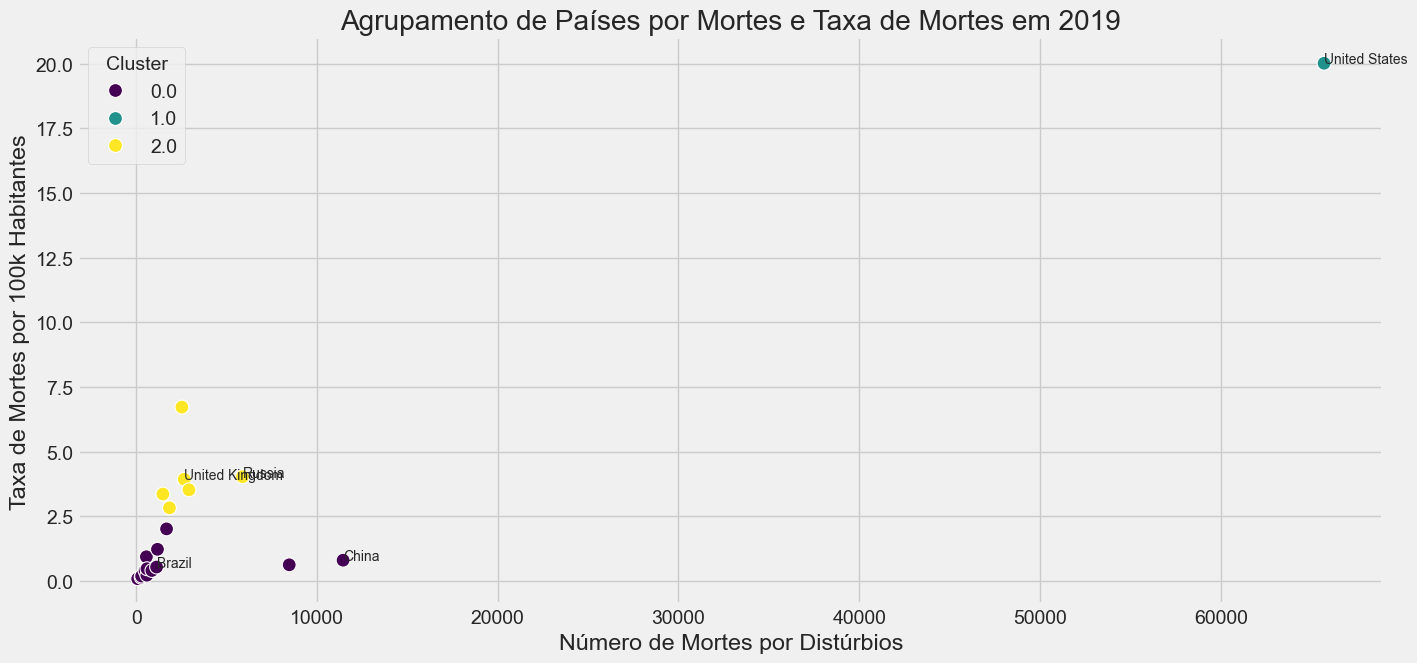

In [18]:
df_2019_ml = df_death[df_death['Year'] == 2019].copy()

features = df_2019_ml[['Deaths_Drug_Use_Disorders', 'Deaths_per_100k']].dropna()

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_2019_ml.loc[features.index, 'Cluster'] = kmeans.fit_predict(features_scaled)

plt.figure(figsize=(15, 7))
sns.scatterplot(
    data=df_2019_ml,
    x='Deaths_Drug_Use_Disorders',
    y='Deaths_per_100k',
    hue='Cluster',
    palette='viridis',
    s=100
)

for i, country in enumerate(df_2019_ml['COUNTRY']):
    if country in ['United States', 'China', 'Russia', 'United Kingdom', 'Brazil']:
        plt.text(
            df_2019_ml.iloc[i]['Deaths_Drug_Use_Disorders'],
            df_2019_ml.iloc[i]['Deaths_per_100k'],
            country,
            fontsize=10
        )

plt.title('Agrupamento de Países por Mortes e Taxa de Mortes em 2019')
plt.xlabel('Número de Mortes por Distúrbios')
plt.ylabel('Taxa de Mortes por 100k Habitantes')
plt.legend(title='Cluster')
plt.show()

A crise de drogas nos Estados Unidos é de uma magnitude completamente diferente das outras nações, que se agrupam em patamares muito mais baixos de mortes e taxas de mortalidade.

In [19]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f'O Erro Quadrático Médio (MSE) do modelo é: {mse:.2f}')

O Erro Quadrático Médio (MSE) do modelo é: 23349867.57


In [20]:
cluster_summary = df_2019_ml.groupby('Cluster')[['Deaths_Drug_Use_Disorders', 'Deaths_per_100k']].mean().sort_values(by='Deaths_Drug_Use_Disorders', ascending=False)
print("Resumo dos Clusters:")
print(cluster_summary)

print("Países em cada cluster:")
for i in range(3):
    print(f"Cluster {i}:")
    print(df_2019_ml[df_2019_ml['Cluster'] == i]['COUNTRY'].unique())

Resumo dos Clusters:
         Deaths_Drug_Use_Disorders  Deaths_per_100k
Cluster                                            
1.0                   65717.000000        20.021050
2.0                    2881.833333         4.062916
0.0                    2127.000000         0.614278
Países em cada cluster:
Cluster 0:
['Egypt' 'Nigeria' 'Bangladesh' 'Japan' 'Italy' 'Indonesia' 'Mexico'
 'Pakistan' 'Brazil' 'Vietnam' 'Germany' 'India' 'China']
Cluster 1:
['United States']
Cluster 2:
['Ukraine' 'France' 'Canada' 'United Kingdom' 'Iran' 'Russia']


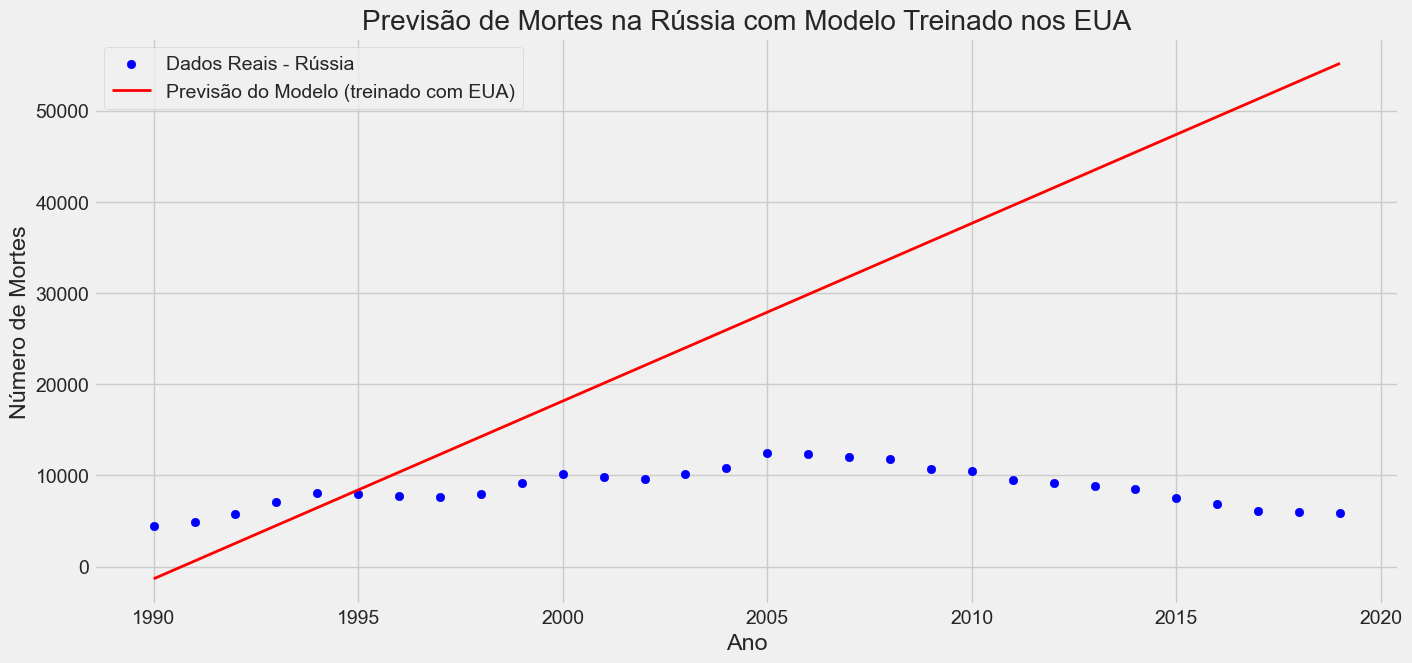

In [21]:
#Rússia
df_russia = df_death[df_death['COUNTRY'] == 'Russia']
X_russia = df_russia[['Year']]
y_russia = df_russia['Deaths_Drug_Use_Disorders']

y_russia_pred = model.predict(X_russia)

plt.figure(figsize=(15, 7))
plt.scatter(X_russia, y_russia, color='blue', label='Dados Reais - Rússia')
plt.plot(X_russia, y_russia_pred, color='red', linewidth=2, label='Previsão do Modelo (treinado com EUA)')
plt.title('Previsão de Mortes na Rússia com Modelo Treinado nos EUA')
plt.xlabel('Ano')
plt.ylabel('Número de Mortes')
plt.legend()
plt.show()

A grande disparidade entre a previsão e os dados reais sugere que os fatores que impulsionam as mortes por drogas nos EUA são fundamentalmente diferentes daqueles que afetam a Rússia. Portanto, um modelo baseado na realidade de um país não pode ser aplicado de forma eficaz a outro.

11:44:58 - cmdstanpy - INFO - Chain [1] start processing
11:44:58 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


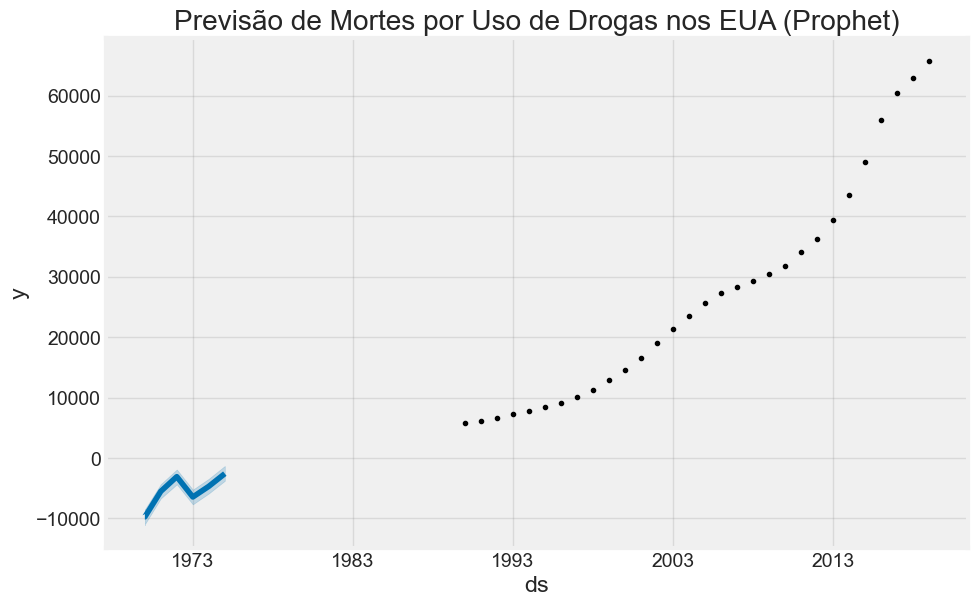

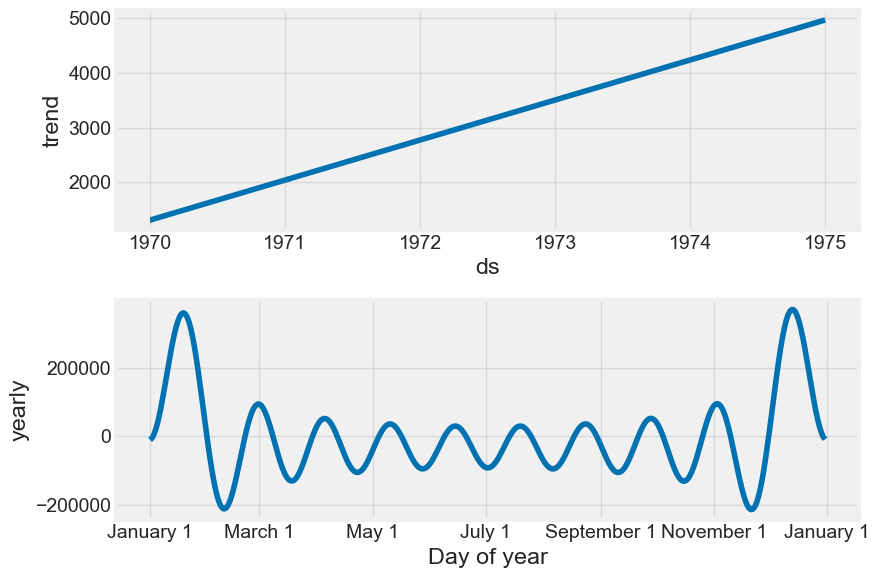

In [22]:
#Predição
df_prophet = df_death[df_death['COUNTRY'] == 'United States'][['Year', 'Deaths_Drug_Use_Disorders']].copy()
df_prophet.rename(columns={'Year': 'ds', 'Deaths_Drug_Use_Disorders': 'y'}, inplace=True)

m = Prophet()
m.fit(df_prophet)

future = m.make_future_dataframe(periods=5, freq='Y')

forecast = m.predict(future)

fig = m.plot(forecast)
plt.title('Previsão de Mortes por Uso de Drogas nos EUA (Prophet)')
plt.show()

fig2 = m.plot_components(forecast)
plt.show()

O modelo de previsão, que se baseia em uma tendência linear e em uma sazonalidade, pode não ser suficiente para capturar a natureza acelerada do aumento das mortes por uso de drogas nos EUA, o que pode levar a subestimativas futuras, como já observado em outros gráficos.

In [23]:
#Correlção
print("Correlação entre mortes e taxa de mortes (dados gerais):")
print(df_2019_ml[['Deaths_Drug_Use_Disorders', 'Deaths_per_100k']].corr())

for cluster_id in df_2019_ml['Cluster'].unique():
    cluster_data = df_2019_ml[df_2019_ml['Cluster'] == cluster_id]
    if len(cluster_data) > 1:
        print(f"Correlação no Cluster {cluster_id}")
        print(cluster_data[['Deaths_Drug_Use_Disorders', 'Deaths_per_100k']].corr())

Correlação entre mortes e taxa de mortes (dados gerais):
                           Deaths_Drug_Use_Disorders  Deaths_per_100k
Deaths_Drug_Use_Disorders                   1.000000         0.909323
Deaths_per_100k                             0.909323         1.000000
Correlação no Cluster 0.0
                           Deaths_Drug_Use_Disorders  Deaths_per_100k
Deaths_Drug_Use_Disorders                   1.000000         0.191758
Deaths_per_100k                             0.191758         1.000000
Correlação no Cluster 2.0
                           Deaths_Drug_Use_Disorders  Deaths_per_100k
Deaths_Drug_Use_Disorders                   1.000000         0.115837
Deaths_per_100k                             0.115837         1.000000


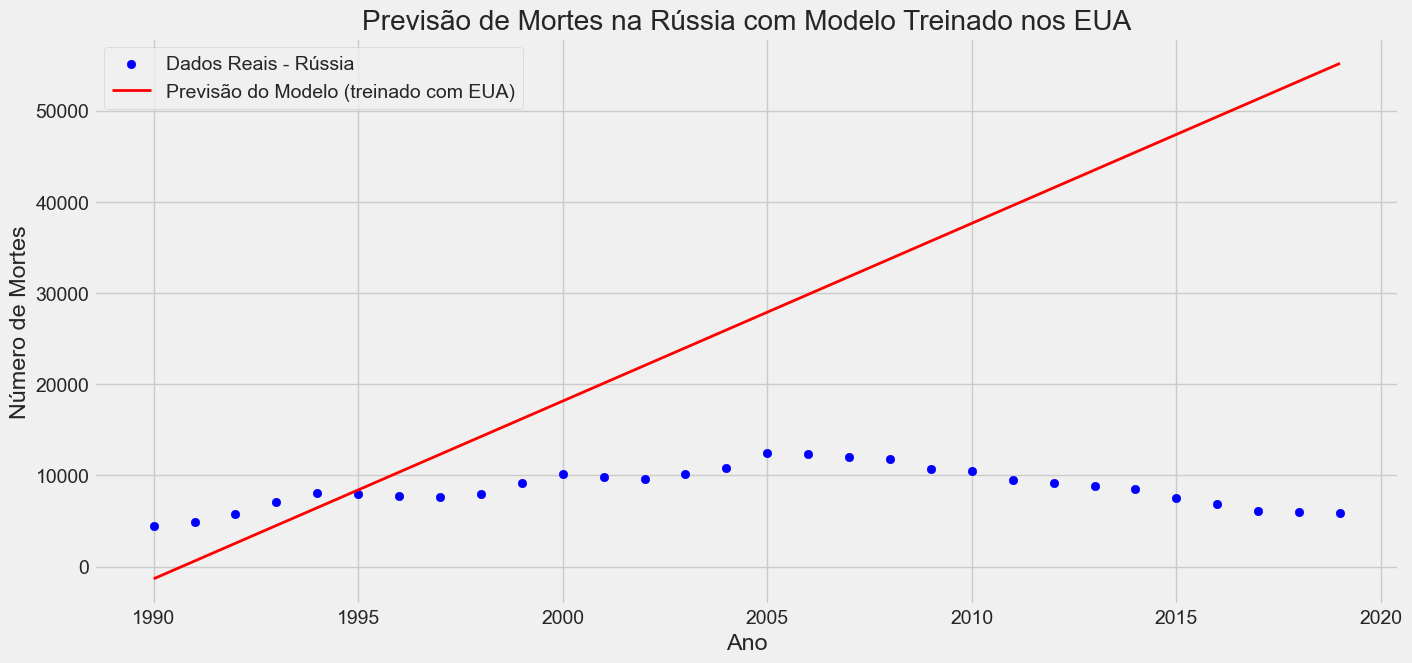

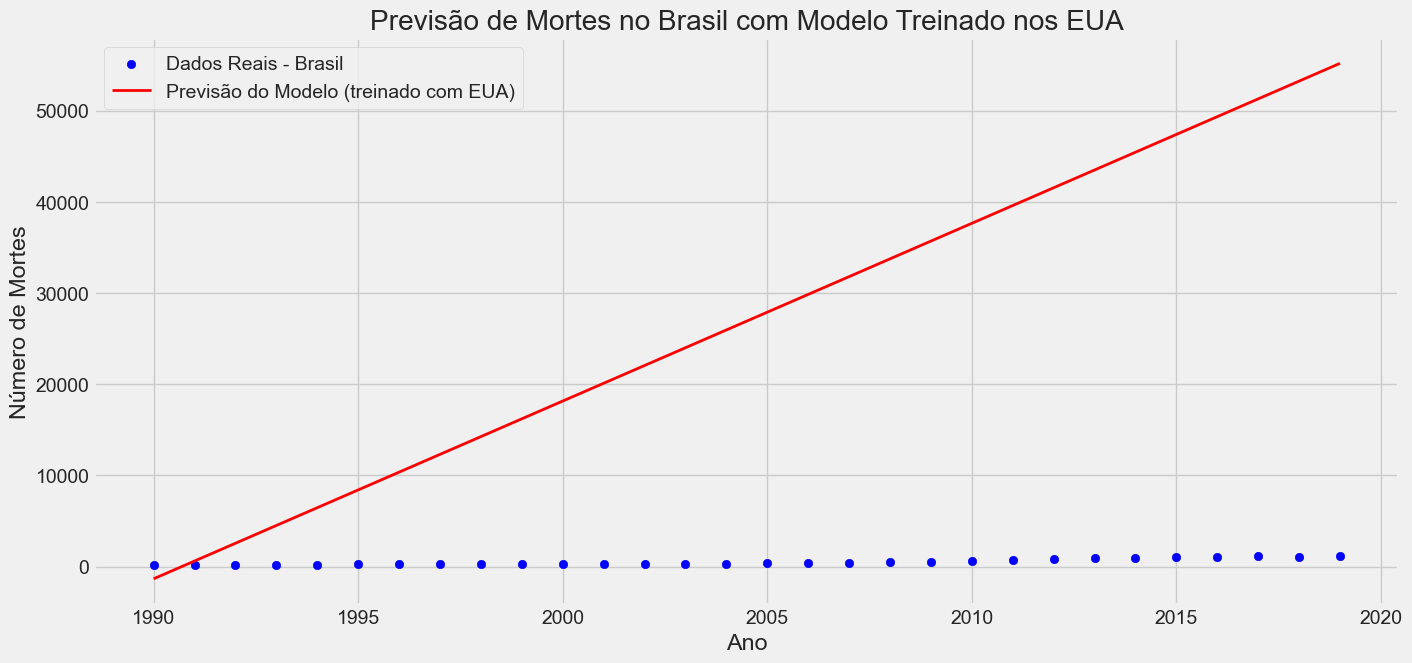

In [24]:
#Analisando a Rússia
df_russia = df_death[df_death['COUNTRY'] == 'Russia']
X_russia = df_russia[['Year']]
y_russia = df_russia['Deaths_Drug_Use_Disorders']

y_russia_pred = model.predict(X_russia)

plt.figure(figsize=(15, 7))
plt.scatter(X_russia, y_russia, color='blue', label='Dados Reais - Rússia')
plt.plot(X_russia, y_russia_pred, color='red', linewidth=2, label='Previsão do Modelo (treinado com EUA)')
plt.title('Previsão de Mortes na Rússia com Modelo Treinado nos EUA')
plt.xlabel('Ano')
plt.ylabel('Número de Mortes')
plt.legend()
plt.show()

#Analisando o Brasil
df_brazil = df_death[df_death['COUNTRY'] == 'Brazil']
X_brazil = df_brazil[['Year']]
y_brazil = df_brazil['Deaths_Drug_Use_Disorders']

y_brazil_pred = model.predict(X_brazil)

plt.figure(figsize=(15, 7))
plt.scatter(X_brazil, y_brazil, color='blue', label='Dados Reais - Brasil')
plt.plot(X_brazil, y_brazil_pred, color='red', linewidth=2, label='Previsão do Modelo (treinado com EUA)')
plt.title('Previsão de Mortes no Brasil com Modelo Treinado nos EUA')
plt.xlabel('Ano')
plt.ylabel('Número de Mortes')
plt.legend()
plt.show()

A análise conjunta dos gráficos demonstra que modelos preditivos baseados em dados de um país (neste caso, os EUA) não podem ser generalizados para outros, pois as dinâmicas sociais, econômicas e de saúde pública que influenciam as mortes por drogas variam drasticamente entre as nações.

In [25]:
from sklearn.ensemble import RandomForestRegressor
X = df_us[['Year']]
y = df_us['Deaths_Drug_Use_Disorders']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f'Erro Quadrático Médio do RandomForest: {mse_rf:.2f}')

Erro Quadrático Médio do RandomForest: 2583922.72


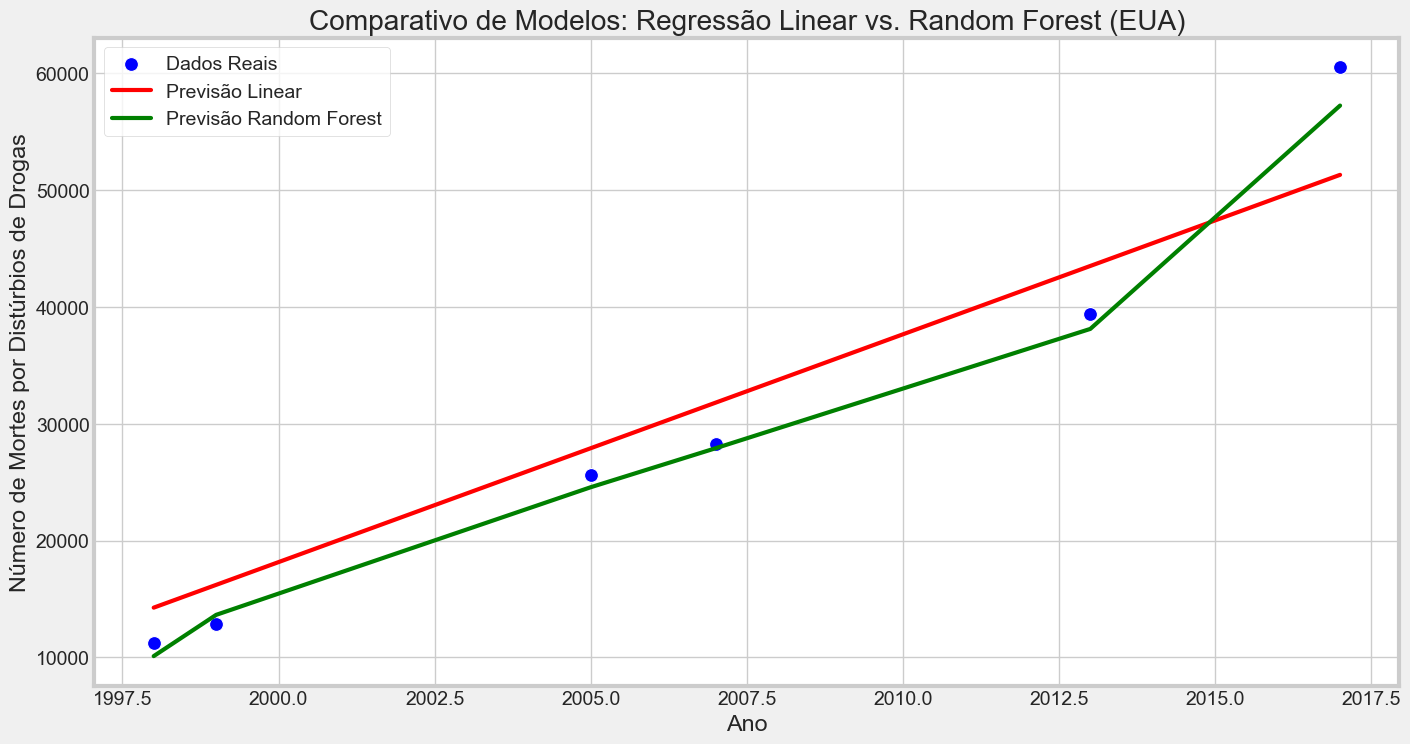

In [26]:
#Comparação dos Modelos
plot_df = pd.DataFrame({
    'Year': X_test.squeeze(),
    'Real': y_test,
    'Linear_Prediction': y_pred,
    'RandomForest_Prediction': y_pred_rf
})

plot_df.sort_values(by='Year', inplace=True)

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

sns.scatterplot(data=plot_df, x='Year', y='Real', color='blue', s=100, label='Dados Reais')

sns.lineplot(data=plot_df, x='Year', y='Linear_Prediction', color='red', linewidth=3, label='Previsão Linear')

sns.lineplot(data=plot_df, x='Year', y='RandomForest_Prediction', color='green', linewidth=3, label='Previsão Random Forest')

plt.title('Comparativo de Modelos: Regressão Linear vs. Random Forest (EUA)')
plt.xlabel('Ano')
plt.ylabel('Número de Mortes por Distúrbios de Drogas')
plt.legend()
plt.show()

Isso sugere que a relação entre o ano e o número de mortes não é linear, e que modelos mais complexos, como o Random Forest, são mais eficazes para prever a tendência crescente e volátil.

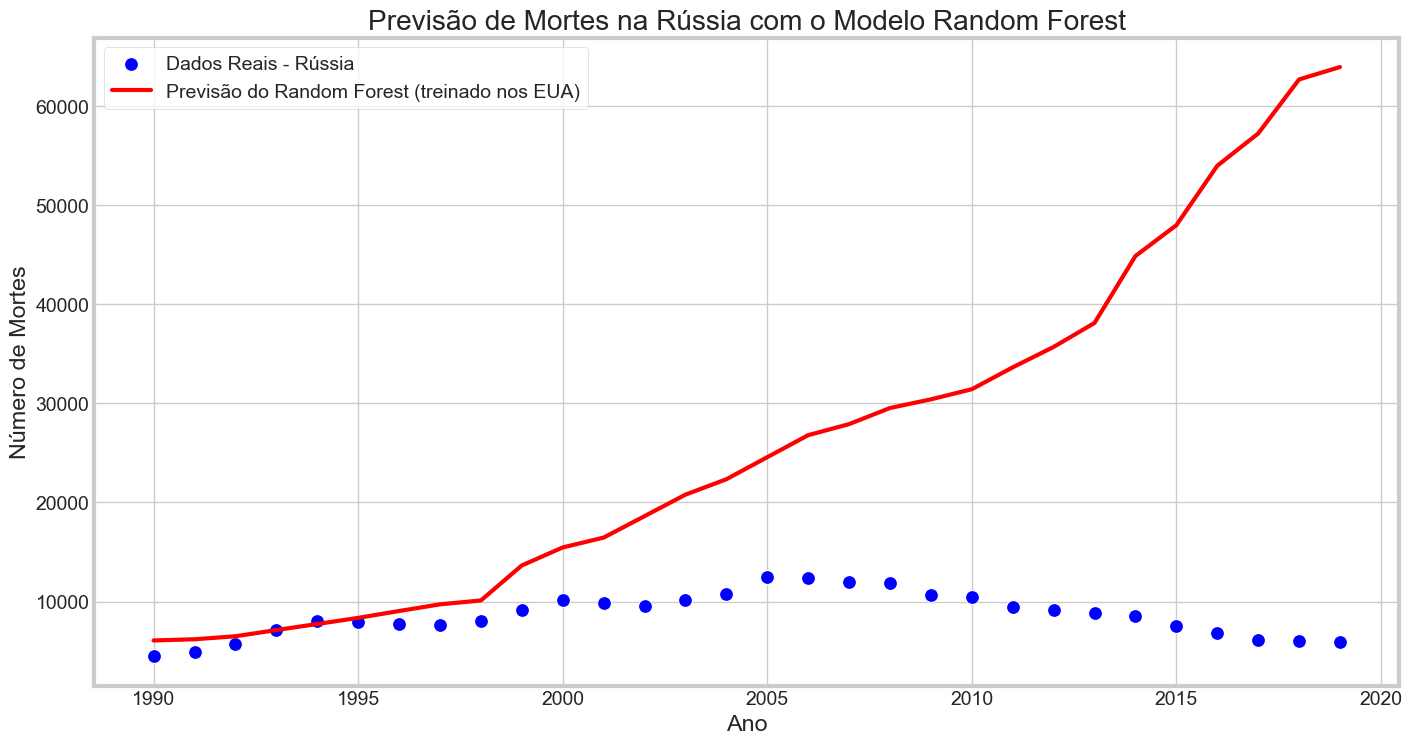

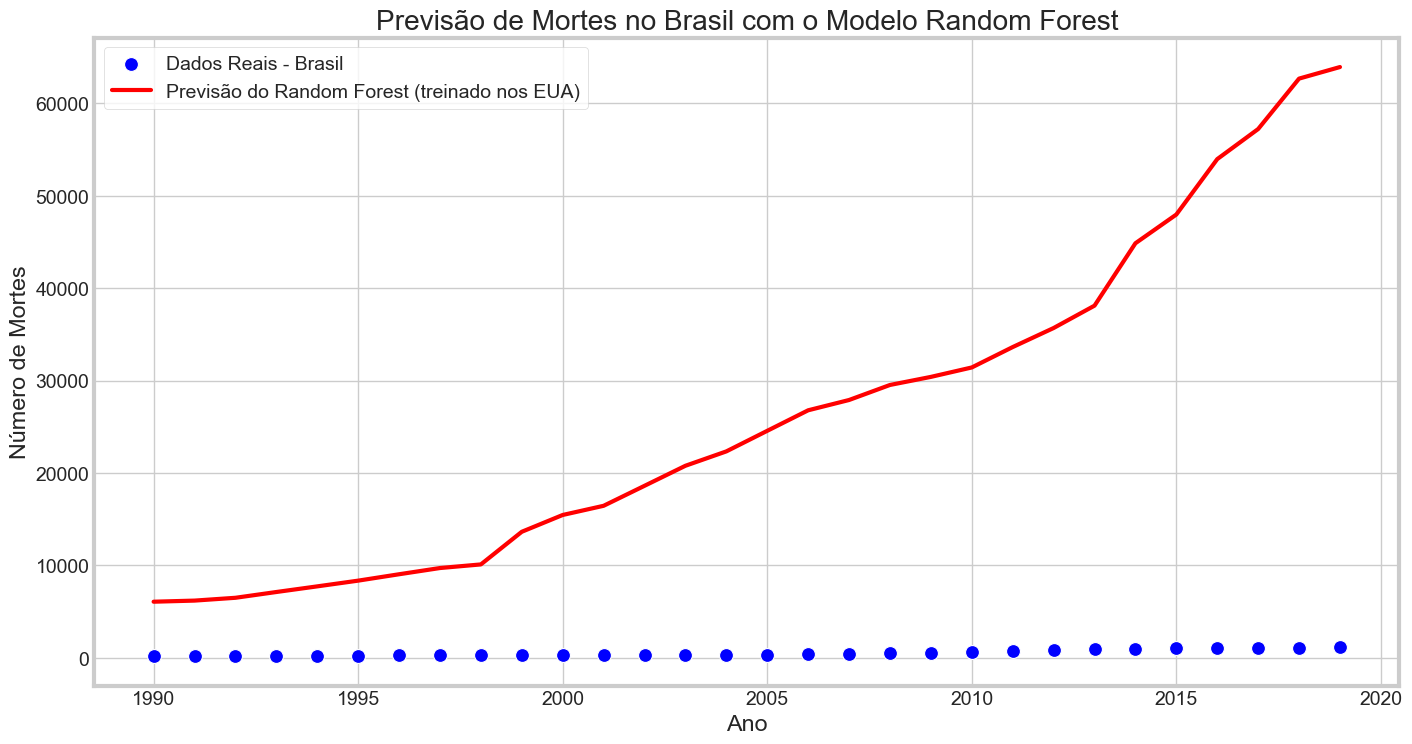

In [27]:
#Analisando a Rússia
df_russia = df_death[df_death['COUNTRY'] == 'Russia']
X_russia = df_russia[['Year']]
y_russia = df_russia['Deaths_Drug_Use_Disorders']

y_russia_pred_rf = rf_model.predict(X_russia)

plt.figure(figsize=(15, 8))
sns.scatterplot(x=X_russia['Year'], y=y_russia, color='blue', s=100, label='Dados Reais - Rússia')
sns.lineplot(x=X_russia['Year'], y=y_russia_pred_rf, color='red', linewidth=3, label='Previsão do Random Forest (treinado nos EUA)')
plt.title('Previsão de Mortes na Rússia com o Modelo Random Forest')
plt.xlabel('Ano')
plt.ylabel('Número de Mortes')
plt.legend()
plt.show()

df_brazil = df_death[df_death['COUNTRY'] == 'Brazil']
X_brazil = df_brazil[['Year']]
y_brazil = df_brazil['Deaths_Drug_Use_Disorders']

y_brazil_pred_rf = rf_model.predict(X_brazil)

plt.figure(figsize=(15, 8))
sns.scatterplot(x=X_brazil['Year'], y=y_brazil, color='blue', s=100, label='Dados Reais - Brasil')
sns.lineplot(x=X_brazil['Year'], y=y_brazil_pred_rf, color='red', linewidth=3, label='Previsão do Random Forest (treinado nos EUA)')
plt.title('Previsão de Mortes no Brasil com o Modelo Random Forest')
plt.xlabel('Ano')
plt.ylabel('Número de Mortes')
plt.legend()
plt.show()

Mesmo um modelo de previsão mais sofisticado como o Random Forest, quando treinado com dados de um único país (neste caso, os EUA), não consegue capturar com precisão a dinâmica da crise de drogas em outras nações como a Rússia e o Brasil.

In [28]:
#Previsão
future_years = np.array([[2025], [2030], [2035]])
future_years_df = pd.DataFrame(future_years, columns=['Year'])

future_deaths = rf_model.predict(future_years_df)

print("Previsões de mortes nos EUA:")
for year, deaths in zip(future_years.flatten(), future_deaths):
    print(f"Ano: {year}, Mortes previstas: {int(deaths):,}".replace(',', '.'))

Previsões de mortes nos EUA:
Ano: 2025. Mortes previstas: 63.928
Ano: 2030. Mortes previstas: 63.928
Ano: 2035. Mortes previstas: 63.928


# Conclusão

A forte relação entre o número de mortes e a taxa de mortes por 100 mil habitantes, observada nos dados gerais, é na verdade causada pelos EUA. Para a maioria dos outros países, essa correlação é fraca, indicando que a dinâmica do problema é completamente diferente para cada grupo.
A crise de mortes por distúrbios de uso de drogas é uma realidade complexa e, embora seja um problema global, os dados indicam que sua manifestação é desproporcional entre as nações. Enquanto países como a Rússia e o Brasil mantêm números baixos ou em queda, a crise é particularmente severa na América do Norte, que registrou um crescimento vertiginoso nas últimas décadas.
"Mortes por Distúrbios" com "Mortes Atribuídas" mostra que a grande maioria das mortes não é resultado de condições crônicas de saúde decorrentes do uso de drogas (que a maioria dos modelos ignora), mas sim de eventos agudos e letais, como overdoses.
o Random Forest, falharam em prever a crise fora dos EUA, tanto na Rússia quanto no Brasil, onde os números são baixos e/ou em queda. Isso demonstra que modelos criados a partir dos dados de um único país não podem ser aplicados a outro. Isso se deve, provavelmente, a fatores sociais, políticos e culturais que são únicos a cada nação.
A crise de mortes por uso de drogas é predominantemente um problema da América do Norte, impulsionado por mortes agudas e com uma tendência de piora acentuada, o que exige abordagens específicas e localizadas, e não a aplicação de modelos generalistas.

# **Nathália Sorg**